## Imports


In [5]:
import sys, torch, scprep
sys.path.append('../')
import warnings; warnings.filterwarnings('ignore')
from torch import optim
import torchvision; from torchvision import datasets, transforms
import numpy as np
import matplotlib; import matplotlib.pyplot as plt
import graphtools as gt
import networkx as nx
import scipy
from torch import nn
from abc import abstractmethod
from typing import List, Callable, Union, Any, TypeVar, Tuple

## Loading Datasets  

### MNIST Dataset

In [ ]:
# --- Load MNIST ---
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
X = mnist.data.numpy().reshape(60000, -1)   # raw pixels (0–255)
y = mnist.targets.numpy()

# --- Balanced sample: 1000 per digit ---
idx = np.hstack([np.random.choice(np.where(y == d)[0], 1000, replace=False) for d in range(10)])
X_subset = X[idx]    # (10000, 784)

# --- Linear version (features × samples), range [0,1] ---
MNIST_v1 = torch.from_numpy((X_subset / 255).T).double()   

# --- Deep-learning version (samples × features), range [-1,1] ---
MNIST_v2 = torch.from_numpy((X_subset / 255 * 2 - 1)).double() 

# --- Diagnostics ---
print("MNIST_v1:", MNIST_v1.shape,
      "range:", (MNIST_v1.min().item(), MNIST_v1.max().item()))

print("MNIST_v2:    ", MNIST_v2.shape,
      "range:", (MNIST_v2.min().item(), MNIST_v2.max().item()))


MNIST_v1: torch.Size([784, 10000]) range: (0.0, 1.0)
MNIST_v2:     torch.Size([10000, 784]) range: (-1.0, 1.0)


### Sequence RNA dataset

In [2]:
#Download data also available at https://www.kaggle.com/datasets/alexandervc/scrnaseq-scatacseq-challenge-at-neurips-2021
import os
import urllib.request

# Define the local filename
destination = "./data/GSE194122_openproblems_neurips2021_multiome_BMMC_processed.h5ad"

# This is the direct link to the processed challenge dataset on Figshare
# (Maintained by the Open Problems team)
url = "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE194122&format=file&file=GSE194122%5Fopenproblems%5Fneurips2021%5Fmultiome%5FBMMC%5Fprocessed%2Eh5ad%2Egz" 

print(f"Downloading dataset from original source (Figshare)...")

if not os.path.exists(destination):
    urllib.request.urlretrieve(url, destination)
    print("Download complete!")
else:
    print("File already exists.")

File already exists.


In [3]:
import scanpy as sc

# Load normally with Scanpy
import scanpy as sc


fn = './data/GSE194122_openproblems_neurips2021_multiome_BMMC_processed.h5ad'
adata = sc.read(fn)
print(adata)

# 1. Subsample 1000 cells
# We use copy=True so we don't accidentally modify your original massive 'adata' object
adata_subset = sc.pp.subsample(adata, n_obs=1000, copy=True, random_state=42)

# 2. Extract the PCA matrix
# This is currently a numpy array of shape (1000, 50)
pca_data = adata_subset.obsm['GEX_X_pca']

# 3. Select the top N components
# Standard practice is often the top50, as lower components (e.g., 40-50) might be noise.
n_components = 50
pca_data_top = pca_data[:, :n_components]


# 1. Re-create the tensor as float64 (Double)
#    Note: .T is added here to transpose it as you mentioned
sequRNA_train = torch.tensor(pca_data_top, dtype=torch.float64).T

# 2. Move to the correct device (if you are using GPU, otherwise skip)
#    The error trace mentions 'device', so it's good practice to be explicit.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
sequRNA_train = sequRNA_train.to(device)

# 3. Verify shapes
#    AALS usually expects (Features x Samples) or (Samples x Features). 
#    Since you transposed, you now have (30 x 1000). 
print(f"Input shape: {sequRNA_train.shape}") 
print(f"Input type: {sequRNA_train.dtype}")  # Should say torch.float64


''' 
This is ready for Linear AA, slight modification might be needed for other models
'''

AnnData object with n_obs × n_vars = 69249 × 129921
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker'
    var: 'feature_types', 'gene_id'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'
Using device: cpu
Input shape: torch.Size([50, 1000])
Input type: torch.float64


' \nThis is ready for Linear AA, slight modification might be needed for other models\n'

general Functions:  
NMI  
Confidence  
...

In [4]:
from scipy.spatial.distance import pdist, squareform
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'




def ArchetypeConsistency(XC1, XC2, mSST):
    """
    Calculates the consistency between two sets of archetypes (XC1 and XC2).
    """
    # 1. Calculate Squared Euclidean Distance between all archetypes
    D = squareform(pdist(np.hstack((XC1, XC2)).T, 'euclidean'))**2
    D = D[:XC1.shape[1], XC1.shape[1]:]

    # 2. Greedy Matching to pair archetypes
    i = []
    j = []
    v = []
    K = XC1.shape[1]
    
    for k in range(K):
        # Find minimum distance in the matrix
        min_index = np.unravel_index(np.argmin(D, axis=None), D.shape)
        i.append(min_index[0])
        j.append(min_index[1])
        v.append(D[i[-1], j[-1]]) # Record the error (distance)
        
        # 'Remove' these from future consideration
        D[i[-1], :] = np.inf
        D[:, j[-1]] = np.inf

    # 3. Calculate Consistency Score (R^2-like metric)
    consistency = 1 - np.mean(v) / mSST

    # 4. Calculate Inter-Set Similarity Index (ISI)
    # Correlation between matched archetypes
    D2 = np.abs(np.corrcoef(np.hstack((XC1, XC2)).T))
    D2 = D2[:K, K:]
    ISI = 1 / (2 * K * (K - 1)) * (np.sum(D2 / np.max(D2, axis=1, keepdims=True) + D2 / np.max(D2, axis=0, keepdims=True)) - 2 * K)
    
    return consistency, ISI

def preprocess(X):
    """
    Mean-centers the data and computes the total variance (mSST).
    """
    meanX = np.mean(X, axis=0)
    X_centered = X - meanX
    # Mean Sum of Squares Total (Total Variance)
    mSST = np.sum(np.mean(X_centered**2, axis=0))
    return X_centered, mSST

def calcMI(z1,z2):
    eps = 10e-16
    P = z1@z2.T
    PXY = P/P.sum()
    PXPY = np.outer(np.expand_dims(PXY.sum(1), axis=0),np.expand_dims(PXY.sum(0), axis=1))
    ind = np.nonzero(PXY>0)
    MI = np.sum(PXY*np.log(eps+PXY/(eps+PXPY)))
    return MI
    
def calcNMI(z1,z2):
    NMI=(2*calcMI(z1,z2))/(calcMI(z1,z1)+calcMI(z2,z2))
    #NMI = NMI.reshape((z1.shape[0], z1.shape[0]))
    
    return NMI

def plot_loss_arc(L,n_arc_list,i,color,model, dataset, savedir = None):


    fig, ax = plt.subplots(figsize=(15, 5),layout='constrained')

    ax.errorbar(n_arc_list,np.mean(L,axis=1),yerr=np.std(L,axis=1),c=color,label=f'{model} - {dataset}')

    ##
    # ax.set_xticks(n_arc_list,fontsize=25)
    ax.set_xticks(n_arc_list)       # Set the tick positions
    ax.tick_params(axis='x') # Set the font size separately
    ##

    ax.set_xlabel('Number of Archetypes',fontsize=30)
    ax.set_ylabel('Loss',fontsize=30)

    plt.legend(fontsize=30)

    plt.yticks(fontsize=25)
    plt.xticks(fontsize=25)    
    #plt.title(f'{model} - {dataset}',fontsize=30)

    if savedir is not None:
        plt.savefig(savedir+f"/loss_layer_"+str(i)+".png")
        plt.close()
    else:
        plt.show()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_nmi_stability(NMI,n_arc_list,model,dataset, colors, savedir = None):
    
    
    df = pd.DataFrame(NMI.T)
    df['Method'] = f'Model {model}'


    df = df.melt(id_vars='Method', var_name='Archetypes', value_name='NMI')
    fig, ax = plt.subplots(1,1,figsize = (15,5), layout='constrained')

    ax = sns.boxplot(x='Archetypes', y="NMI", hue="Method", showmeans=True, data=df,palette=colors,meanprops={"marker": "s", "markerfacecolor": "white", "markeredgecolor": "black"})
    ax.xaxis.grid(True, which='major')
    [ax.axvline(x+.5,color='k') for x in ax.get_xticks()]
    plt.xticks(np.arange(len(n_arc_list)),n_arc_list,fontsize=25)
    plt.yticks(fontsize=25)    
    ax.set_xlabel('Number of archetypes', fontsize=30)
    ax.set_ylabel('NMI', fontsize=30)

    ax.set_ylim([0,1.05])
    plt.legend(fontsize=30,loc = 'lower right')
    plt.title(f'{model} - {dataset}',fontsize=30)
    
    if savedir is not None:
        plt.savefig(savedir+f"/NMI_model_"+str(model)+"dataset_"+str(dataset)+".png")
        plt.close()
    else:
        plt.show()

## Linear AA Implementation

In [5]:
from LinearAA.AALS import AALS
import torch
import numpy as np 
import matplotlib.pyplot as plt
from tqdm import tqdm
import itertools
colors = ["#EF476F",  "#06D6A0", "#FFD166", "#073B4C", "#118AB2", "#FF6B6B", "#C8A2C8"]

In [ ]:
# Show small test
# running linear AA on mini subset, 4 times for each archetype, we run it multiple times for each archetype to see stability (NMI)
test_Linear_X = MNIST_linear[:, :50]
n_runs = 4
n_arc_list = [f for f in range(2,15)]
Losses = np.zeros((len(n_arc_list),n_runs))
Ss = np.zeros((len(n_arc_list),n_runs),dtype=object)

for n in tqdm(n_arc_list):
    for i in range(n_runs):

        C,S,L,EV = AALS(test_Linear_X, n)
        Losses[n_arc_list.index(n),i] = L[-1]
        Ss[n_arc_list.index(n),i] = S
        

100%|██████████| 13/13 [00:21<00:00,  1.68s/it]


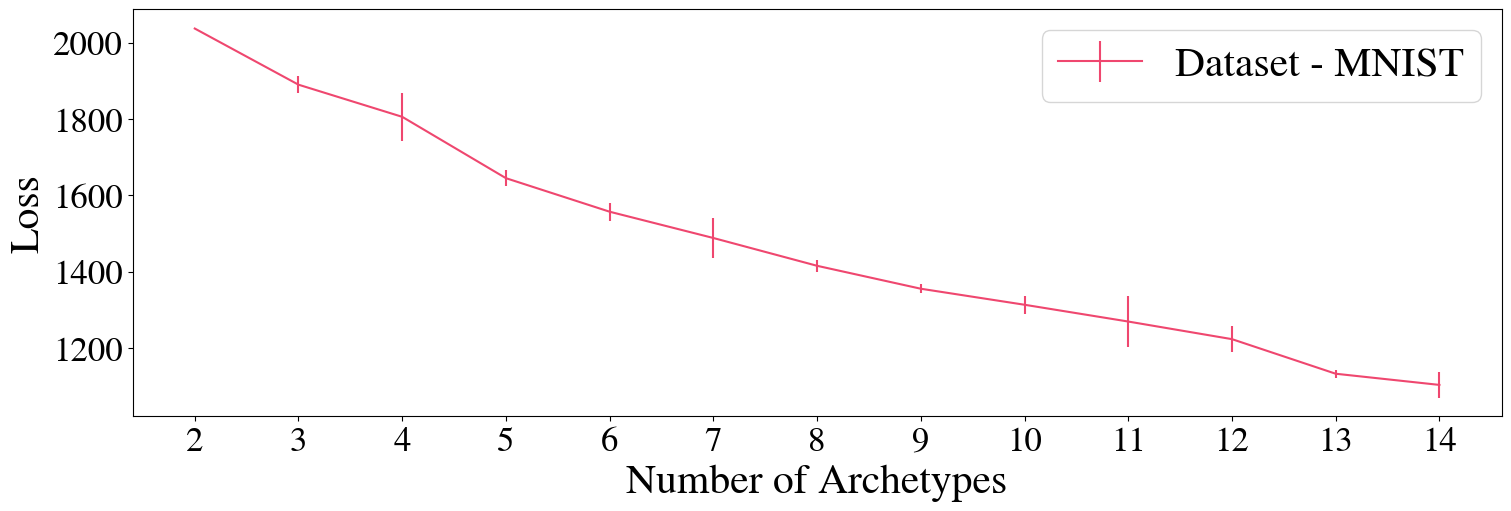

In [7]:
plot_loss_arc(Losses,n_arc_list,i,colors[0],'Dataset', 'MNIST', savedir = None)

100%|██████████| 13/13 [00:00<00:00, 552.62it/s]
C:\Users\fabia\AppData\Local\Temp\ipykernel_12252\2142883590.py:113: UserWarning: The palette list has more values (7) than needed (1), which may not be intended.
  ax = sns.boxplot(x='Archetypes', y="NMI", hue="Method", showmeans=True, data=df,palette=colors,meanprops={"marker": "s", "markerfacecolor": "white", "markeredgecolor": "black"})


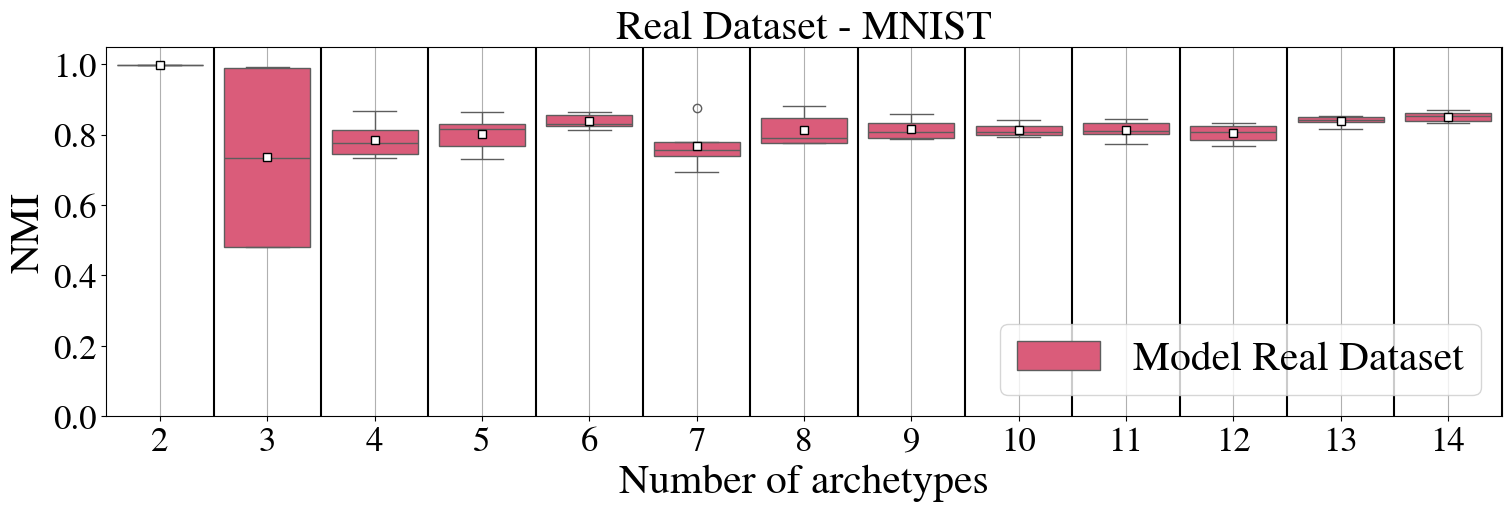

In [8]:
test = itertools.combinations(range(n_runs), 2)
t = list(test)
calcIDX = np.array(t)

NMI = np.zeros((len(n_arc_list),len(calcIDX)))

for n in tqdm(n_arc_list):
    for j in range(len(calcIDX)):

        S1 = np.asarray(Ss[n_arc_list.index(n),calcIDX[j,0]])
        S2 = np.asarray(Ss[n_arc_list.index(n),calcIDX[j,1]])


        NMI[n_arc_list.index(n),j] = calcNMI(S1,S2)

plot_nmi_stability(NMI,n_arc_list, 'Real Dataset','MNIST',colors)

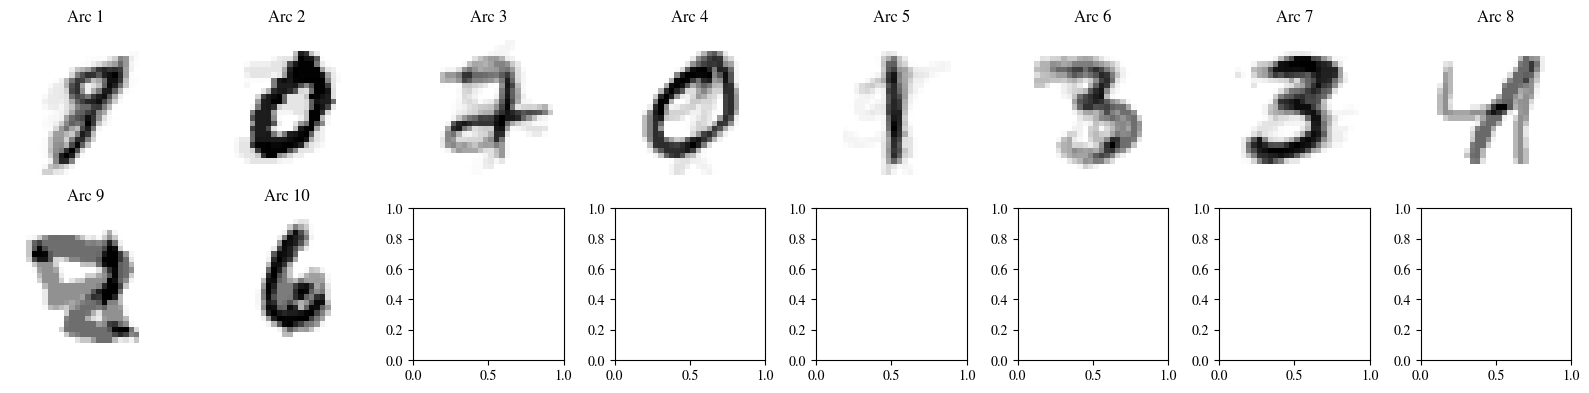

In [9]:
n_archetypes = 10
C_final, S_final, L_final, EV_final = AALS(test_Linear_X, n_archetypes)

# 1. Calculate the actual Archetypes (Z = X * C)
# Ensure both are the same type (likely Torch tensors based on your output)
if isinstance(C_final, np.ndarray):
    C_final = torch.from_numpy(C_final)
if isinstance(test_Linear_X, np.ndarray):
    test_Linear_X = torch.from_numpy(test_Linear_X)

# Matrix Multiplication: (784x100) @ (100x16) -> (784x16)
archetypes_matrix = torch.matmul(test_Linear_X, C_final) 
# 2. Visualize
n_archetypes = archetypes_matrix.shape[1] # Should be 16
rows = int(n_archetypes // 8) + 1  # Adjust grid (2x8 = 16)
cols = 8 # Adjust grid (2x8 = 16)

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 2))
axes = axes.flatten()

for i in range(n_archetypes):
    # Get the i-th archetype (all 784 pixels)
    arc_vector = archetypes_matrix[:, i]
    
    # Reshape to 28x28 image
    arc_img = arc_vector.reshape(28, 28).detach().numpy() # detach if it requires grad
    
    axes[i].imshow(arc_img, cmap='gray_r')
    axes[i].set_title(f"Arc {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## AAnet implementation

In [7]:
def train_epoch(model, data_loader, optimizer, epoch, gamma_reconstruction=1.0, gamma_archetypal=1.0, gamma_extrema=1.0):
    loss = 0
    reconstruction_loss = 0
    archetypal_loss = 0
    extrema_loss = 0

    for idx, data in enumerate(data_loader):
        
        # if input is list, then data_loader contains features and target
        # assume first input is features based on data_loader structure
        if isinstance(data, list):
            batch_features = data[0]
        else:
            batch_features = data
        
        # if there are extrema, add diffusion extrema to beginning of each batch
        # first n_archetypes samples are used in extrema loss
        if model.diffusion_extrema is not None:
            batch_features = torch.cat((model.diffusion_extrema.view(-1, model.input_shape),
                                    batch_features.view(-1, model.input_shape)), 0)
            
        # reshape mini-batch data to [N, input_shape] matrix
        batch_features = batch_features.view(-1, model.input_shape)
        
        # load it to the active device
        batch_features = batch_features.to(model.device)

        # reset the gradients back to zero
        # PyTorch accumulates gradients on subsequent backward passes
        optimizer.zero_grad()

        # compute reconstructions
        output, _in, archetypal_embedding = model(batch_features.float())

        # compute training reconstruction loss
        curr_reconstruction_loss = torch.mean((output - batch_features)**2)
        reconstruction_loss += curr_reconstruction_loss

        # compute training archetypal loss
        curr_archetypal_loss = model.calc_archetypal_loss(archetypal_embedding)
        archetypal_loss += curr_archetypal_loss
        
        # compute training diffusion extrema loss
        if model.diffusion_extrema is not None:
            curr_extrema_loss = model.calc_diffusion_extrema_loss(archetypal_embedding)
            extrema_loss += curr_extrema_loss
        else:
            curr_extrema_loss = 0
            extrema_loss = 0
            
        # extrema penalization decreases over batches and epochs
        # this enables AAnet to learn the correct archetypes if the diffusion extrema are not close
        train_loss = gamma_reconstruction * curr_reconstruction_loss + \
                     gamma_archetypal * curr_archetypal_loss + \
                     gamma_extrema /(epoch * len(data_loader) + (idx+1)) * curr_extrema_loss

        # compute accumulated gradients
        train_loss.backward()

        # perform parameter update based on current gradients
        optimizer.step()

        # add the mini-batch training loss to epoch loss
        loss += train_loss.item()

    # compute the epoch training loss
    loss = loss / len(data_loader)
    reconstruction_loss = reconstruction_loss / len(data_loader)
    archetypal_loss = archetypal_loss / len(data_loader)
    return loss, reconstruction_loss, archetypal_loss

In [8]:
class AAnet_vanilla(nn.Module):
    def __init__(
        self,
        input_shape,
        n_archetypes=4,
        noise=0,
        layer_widths=[128, 128],
        activation_out="tanh",
        simplex_scale=1,
        device=None,
        diffusion_extrema=None,
        **kwargs
    ):
        super().__init__()

        self.input_shape = input_shape
        self.n_archetypes = n_archetypes
        self.noise = noise
        self.layer_widths = layer_widths
        self.activation_out = activation_out
        self.simplex_scale = simplex_scale
        self.diffusion_extrema = diffusion_extrema
        
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = device

        # ---------------------------
        # Encoder network
        # ---------------------------
        self.encoder_layers = nn.ModuleList()
        for i, width in enumerate(layer_widths):
            in_features = input_shape if i == 0 else layer_widths[i - 1]
            self.encoder_layers.append(nn.Linear(in_features, width))

        # Last encoder layer → latent dims = n_archetypes - 1
        self.encoder_layers.append(nn.Linear(layer_widths[-1], n_archetypes - 1))

        # ---------------------------
        # Decoder network
        # ---------------------------
        self.decoder_layers = nn.ModuleList()
        decoder_widths = layer_widths[::-1]

        for i, width in enumerate(decoder_widths):
            in_features = n_archetypes - 1 if i == 0 else decoder_widths[i - 1]
            self.decoder_layers.append(nn.Linear(in_features, width))

        # Last decoder layer → reconstruct input
        self.decoder_layers.append(
            nn.Linear(decoder_widths[-1], input_shape)
        )

        # Precompute archetypal simplex
        self.archetypal_simplex = self.get_n_simplex(n_archetypes, simplex_scale)

        self.to(self.device)

    # ============================================================
    # Utility functions (migrated from BaseAAnet)
    # ============================================================

    def get_n_simplex(self, n=2, scale=1):
        """Returns an n-simplex centered at the origin."""
        nth = (1/(n-1)*(1-np.sqrt(n))) * np.ones(n-1)
        D = np.vstack([np.eye(n-1), nth]) * scale
        return torch.tensor(D - np.mean(D, axis=0), dtype=torch.float, device=self.device)

    def euclidean_to_barycentric(self, X):
        """Convert Euclidean → barycentric coordinates."""
        simplex = self.archetypal_simplex

        T = torch.zeros((X.shape[1], X.shape[1])).to(self.device)
        for i in range(X.shape[1]):
            for j in range(X.shape[1]):
                T[i, j] = simplex[i, j] - simplex[-1, j]

        T_inv = torch.inverse(T).float().to(self.device)

        X_bary = torch.einsum("ij,bj->bi", T_inv, X - simplex[-1])
        X_bary = torch.cat(
            [X_bary, (1 - torch.sum(X_bary, dim=1, keepdim=True))],
            dim=1
        )
        return X_bary

    def dist_to_simplex(self, X_bary):
        """Distance penalty for barycentric coords outside simplex."""
        return torch.sum(torch.clamp(-X_bary, min=0), dim=1)

    def calc_archetypal_loss(self, archetypal_embedding):
        """Archetypal loss = MSE of distance to simplex."""
        X_bary = self.euclidean_to_barycentric(archetypal_embedding)
        return torch.mean(self.dist_to_simplex(X_bary) ** 2)

    def calc_diffusion_extrema_loss(self, archetypal_embedding):
        """MSE loss between diffusion extrema and simplex vertices."""
        X_bary = self.euclidean_to_barycentric(archetypal_embedding)
        return torch.mean(
            (X_bary[:self.n_archetypes, :] -
             torch.eye(self.n_archetypes, device=self.device)) ** 2
        )

    # ============================================================
    # Encoder / Decoder
    # ============================================================

    def encode(self, x):
        for layer in self.encoder_layers[:-1]:
            x = torch.relu(layer(x))
        return self.encoder_layers[-1](x)  # no activation

    def decode(self, z):
        for layer in self.decoder_layers[:-1]:
            z = torch.relu(layer(z))
        return self.decoder_layers[-1](z)  # no activation

    # ============================================================
    # Forward
    # ============================================================

    def forward(self, x) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Returns:
            recons → reconstructed data
            x → original input
            archetypal_embedding → latent embedding
        """
        z = self.encode(x)
        archetypal_embedding = z.clone()

        if self.noise > 0:
            z = z + torch.normal(0., self.noise, size=z.shape).to(self.device)

        recons = self.decode(z)

        return recons, x, archetypal_embedding


In [12]:
data_loader = torch.utils.data.DataLoader(MNIST_v2, batch_size=256, shuffle=True)
device = torch.device('cpu')
# results will be stored here
reconstruction_losses = {}
archetypal_losses = {}
total_losses = {}

# test archetypes from 5 to 41
for N_ARCHETYPES in range(3, 20):

    print(f"\n==== Testing {N_ARCHETYPES} archetypes ====")


    # 2. Build model
    model = AAnet_vanilla(
        noise=0.05,
        layer_widths=[256, 128],
        n_archetypes=N_ARCHETYPES,
        input_shape=MNIST_v2.shape[1],
        device=device,
        diffusion_extrema=None
    )

    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # 3. Train for a few epochs
    EPOCHS = 20
    last_recon = None

    for epoch in range(1, EPOCHS + 1):
        loss, r_loss, a_loss = train_epoch(
            model, data_loader, optimizer,
            epoch=epoch,
            gamma_reconstruction=1.0,
            gamma_archetypal=1.0,
            gamma_extrema=1.0
        )

        print(f"Epoch {epoch}: recon={r_loss:.5f}  archetypal={a_loss:.5f}  total={loss:.5f}")
        last_recon = r_loss

    # 4. Store the final reconstruction loss for comparison
    reconstruction_losses[N_ARCHETYPES] = float(last_recon)
    archetypal_losses[N_ARCHETYPES] = float(a_loss)
    total_losses[N_ARCHETYPES] = float(loss)

# Done!
print("\n\n=== Summary: Reconstruction Loss by Archetype Count ===")
for k in reconstruction_losses:
    print(f"k={k}: recon_loss={reconstruction_losses[k]:.6f}")


==== Testing 3 archetypes ====
Epoch 1: recon=0.40570  archetypal=0.00219  total=0.40789
Epoch 2: recon=0.26604  archetypal=0.00005  total=0.26609
Epoch 3: recon=0.24479  archetypal=0.00047  total=0.24526
Epoch 4: recon=0.22819  archetypal=0.00031  total=0.22850
Epoch 5: recon=0.22409  archetypal=0.00034  total=0.22443
Epoch 6: recon=0.21800  archetypal=0.00043  total=0.21844
Epoch 7: recon=0.21496  archetypal=0.00054  total=0.21550
Epoch 8: recon=0.21021  archetypal=0.00059  total=0.21080
Epoch 9: recon=0.20861  archetypal=0.00067  total=0.20927
Epoch 10: recon=0.20583  archetypal=0.00067  total=0.20650
Epoch 11: recon=0.20428  archetypal=0.00072  total=0.20500
Epoch 12: recon=0.20261  archetypal=0.00075  total=0.20336
Epoch 13: recon=0.20094  archetypal=0.00082  total=0.20176
Epoch 14: recon=0.20011  archetypal=0.00080  total=0.20091
Epoch 15: recon=0.19832  archetypal=0.00093  total=0.19925
Epoch 16: recon=0.19756  archetypal=0.00086  total=0.19842
Epoch 17: recon=0.19660  archetyp

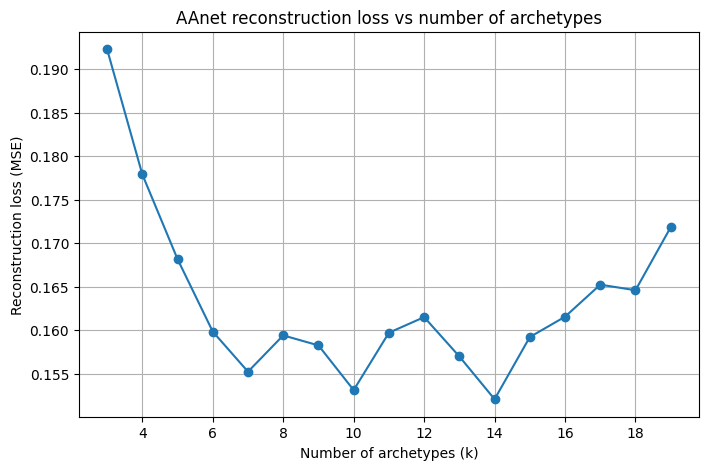

In [13]:
ks = sorted(reconstruction_losses.keys())
losses = [reconstruction_losses[k] for k in ks]

plt.figure(figsize=(8, 5))
plt.plot(ks, losses, marker="o")
plt.xlabel("Number of archetypes (k)")
plt.ylabel("Reconstruction loss (MSE)")
plt.title("AAnet reconstruction loss vs number of archetypes")
plt.grid(True)
plt.show()

## Midaa